In [1]:
!pip install timm

In [2]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
import itertools
from tqdm.autonotebook import tqdm
import albumentations as A
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
import timm

<ipython-input-2-6ed645db08a0>:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.21 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
!pip install kaggle --upgrade
os.environ['KAGGLE_USERNAME'] = "carlosferroz"
os.environ['KAGGLE_KEY'] = "ddbcd2e956ef15466d2999ea1f899b68"

### For Flickr 8k
!kaggle datasets download -d adityajn105/flickr8k
!unzip flickr8k.zip
dataset = "8k"


Streaming output truncated to the last 5000 lines.
  inflating: Images/2844846111_8c1cbfc75d.jpg  
  inflating: Images/2844963839_ff09cdb81f.jpg  
  inflating: Images/2845246160_d0d1bbd6f0.jpg  
  inflating: Images/2845691057_d4ab89d889.jpg  
  inflating: Images/2845845721_d0bc113ff7.jpg  
  inflating: Images/2846037553_1a1de50709.jpg  
  inflating: Images/2846785268_904c5fcf9f.jpg  
  inflating: Images/2846843520_b0e6211478.jpg  
  inflating: Images/2847514745_9a35493023.jpg  
  inflating: Images/2847615962_c330bded6e.jpg  
  inflating: Images/2847859796_4d9cb0d31f.jpg  
  inflating: Images/2848266893_9693c66275.jpg  
  inflating: Images/2848571082_26454cb981.jpg  
  inflating: Images/2848895544_6d06210e9d.jpg  
  inflating: Images/2848977044_446a31d86e.jpg  
  inflating: Images/2849194983_2968c72832.jpg  
  inflating: Images/2850719435_221f15e951.jpg  
  inflating: Images/2851198725_37b6027625.jpg  
  inflating: Images/2851304910_b5721199bc.jpg  
  inflating: Images/2851931813_eaf8ed

In [4]:
import torch
import timm
import torch.nn as nn

class ImageEncoder(nn.Module):
    """
    Encode images to extract feature maps for further processing by Sparse Autoencoder
    """
    def __init__(self, model_name='resnet50', pretrained=True, trainable=False):
        super().__init__()
        self.model = timm.create_model(
            model_name, pretrained=pretrained, num_classes=0, global_pool=""
        )
        # Freeze parameters if trainable is False
        for p in self.model.parameters():
            p.requires_grad = trainable

    def forward(self, x):
        # Extract feature maps from the final convolutional layer
        feature_maps = self.model(x)
        return feature_maps

# Definir el dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_encoder = ImageEncoder().to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SparseAutoencoder(nn.Module):
    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Decoder: Expande la representación para añadir más canales e información
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 4096, kernel_size=3, stride=1, padding=1),  # Expandir a 4096 canales
            nn.ReLU(),
            nn.ConvTranspose2d(4096, 4096, kernel_size=3, stride=1, padding=1),  # Mantener canales pero refinar
            nn.ReLU()
        )

        # Encoder: Comprime la representación para regresar a la dimensión original
        self.encoder = nn.Sequential(
            nn.Conv2d(4096, 2048, kernel_size=3, stride=1, padding=1),  # Reducir a 2048 canales nuevamente
            nn.ReLU(),
            nn.Conv2d(2048, 2048, kernel_size=3, stride=1, padding=1),  # Mantener canales y refinar
            nn.ReLU()
        )

    def forward(self, x):
        # Pasar por el Decoder para expansión
        expanded = self.decoder(x)

        # Pasar por el Encoder para compresión
        compressed = self.encoder(expanded)

        return compressed

# Instanciar el SAE y mover a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sparse_autoencoder = SparseAutoencoder().to(device)

In [6]:
import cv2
import albumentations as A
from torch.utils.data import Dataset, DataLoader

class FlickrDataset(Dataset):
    def __init__(self, image_paths, transforms):
        self.image_paths = image_paths
        self.transforms = transforms

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transforms(image=image)['image']
        return torch.tensor(image).permute(2, 0, 1).float()

    def __len__(self):
        return len(self.image_paths)

def get_transforms():
    return A.Compose([
        A.Resize(224, 224, always_apply=True),
        A.Normalize(max_pixel_value=255.0, always_apply=True),
    ])

# Cargar las imágenes del dataset
import glob

image_paths = glob.glob("/content/Images/*.jpg")  # Ajusta la ruta si es necesario
transforms = get_transforms()
dataset = FlickrDataset(image_paths, transforms)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

Epoch [1/10]: 100%|██████████| 506/506 [03:29<00:00,  2.42it/s, loss=0.116]


Epoch [1/10], Average Loss: 0.1359


Epoch [2/10]: 100%|██████████| 506/506 [03:28<00:00,  2.43it/s, loss=0.0943]


Epoch [2/10], Average Loss: 0.1073


Epoch [3/10]: 100%|██████████| 506/506 [03:27<00:00,  2.44it/s, loss=0.0927]


...

Epoch [8/10], Average Loss: 0.0642


Epoch [9/10]: 100%|██████████| 506/506 [03:27<00:00,  2.43it/s, loss=0.0609]


Epoch [9/10], Average Loss: 0.0611


Epoch [10/10]: 100%|██████████| 506/506 [03:28<00:00,  2.42it/s, loss=0.0563]


Epoch [10/10], Average Loss: 0.0585
Pesos del SAE guardados.


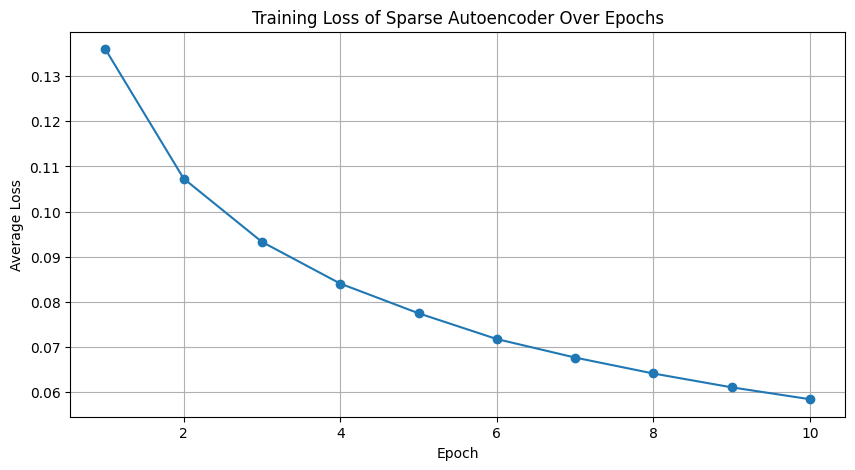

In [7]:
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# Definir el optimizador y la función de pérdida
criterion = nn.MSELoss()
optimizer = optim.Adam(sparse_autoencoder.parameters(), lr=1e-4)

# Lista para almacenar las pérdidas por época
epoch_losses = []

# Número de épocas para el entrenamiento
num_epochs = 10  # Ajusta este valor si es necesario

for epoch in range(num_epochs):
    sparse_autoencoder.train()  # Poner el autoencoder en modo de entrenamiento
    running_loss = 0.0
    progress_bar = tqdm(dataloader, total=len(dataloader), desc=f"Epoch [{epoch + 1}/{num_epochs}]")

    # Entrenamiento sobre cada batch del dataloader
    for images in progress_bar:
        images = images.to(device)

        # Obtener los mapas de características de ResNet-50 (sin actualizar sus pesos)
        with torch.no_grad():
            feature_maps = image_encoder(images)

        # Pasar los mapas de características por el SAE
        optimizer.zero_grad()
        reconstructed = sparse_autoencoder(feature_maps)
        loss = criterion(reconstructed, feature_maps)

        # Backpropagation y optimización
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Actualizar la barra de progreso con la pérdida actual
        progress_bar.set_postfix(loss=loss.item())

    # Promediar la pérdida al final de la época y almacenarla
    epoch_loss = running_loss / len(dataloader)
    epoch_losses.append(epoch_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Average Loss: {epoch_loss:.4f}")

# Guardar los pesos del SAE al final del entrenamiento
torch.save(sparse_autoencoder.state_dict(), "sparse_autoencoder_weights.pth")
print("Pesos del SAE guardados.")

# Gráfica del progreso del entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss of Sparse Autoencoder Over Epochs')
plt.grid(True)
plt.show()

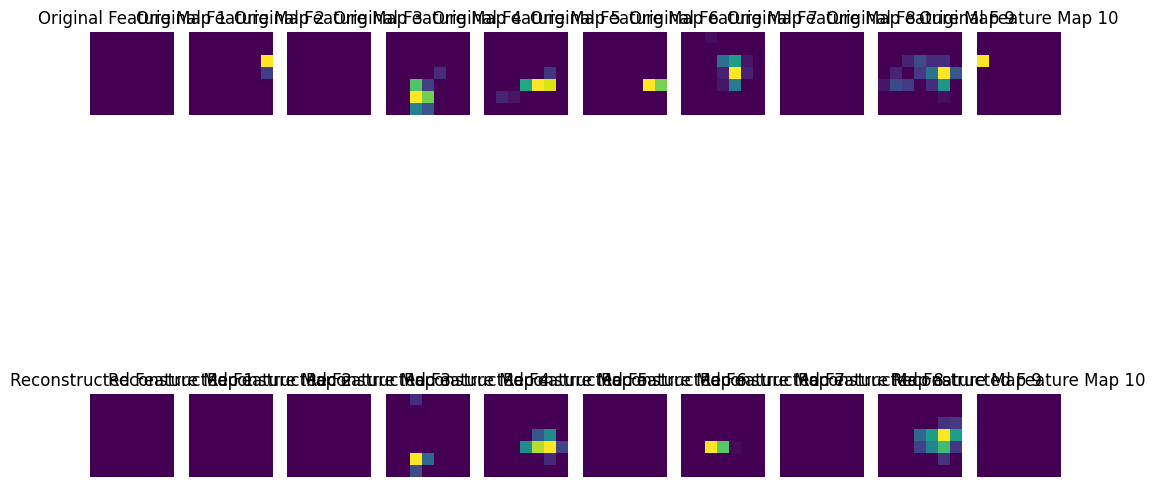

In [15]:
import matplotlib.pyplot as plt

# Modo evaluación para el autoencoder y el encoder de imágenes
sparse_autoencoder.eval()
image_encoder.eval()

# Seleccionar un batch del dataloader
with torch.no_grad():
    images = next(iter(dataloader))  # Obtener un batch del dataloader
    images = images.to(device)

    # Obtener los mapas de características antes del autoencoder
    feature_maps = image_encoder(images)  # Dimensiones esperadas [batch_size, 2048, 7, 7]

    # Pasar los mapas de características a través del SAE para obtener la reconstrucción
    reconstructed_maps = sparse_autoencoder(feature_maps)

# Visualizar una muestra de los mapas originales y reconstruidos
# Mostraremos 4 canales para un ejemplo del batch
num_feature_maps = 10
fig, axes = plt.subplots(2, num_feature_maps, figsize=(10, 10))

for i in range(num_feature_maps):
    # Mapa de características original (antes del SAE)
    original_map = feature_maps[0, i].cpu().numpy()  # Seleccionar el primer ejemplo del batch y el canal i
    # Mapa de características reconstruido (después del SAE)
    reconstructed_map = reconstructed_maps[0, i].cpu().numpy()

    # Visualización del mapa de características original
    axes[0, i].imshow(original_map, cmap='viridis')
    axes[0, i].set_title(f'Original Feature Map {i+1}')
    axes[0, i].axis('off')

    # Visualización del mapa de características reconstruido
    axes[1, i].imshow(reconstructed_map, cmap='viridis')
    axes[1, i].set_title(f'Reconstructed Feature Map {i+1}')
    axes[1, i].axis('off')

# Añadir títulos para identificar las filas
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()

In [16]:
# Liberar memoria innecesaria en la GPU
torch.cuda.empty_cache()

segundo entreno

In [ ]:
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# Definir el optimizador y la función de pérdida
criterion = nn.MSELoss()
optimizer = optim.Adam(sparse_autoencoder.parameters(), lr=1e-4)

# Lista para almacenar las pérdidas por época
epoch_losses = []

# Early stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# Inicializar el early stopping
early_stopping = EarlyStopping(patience=10, min_delta=0.001)

# Número de épocas adicionales para el entrenamiento
num_epochs = 50  # Puedes ajustar el número de épocas según tu necesidad

# Cargar los pesos preentrenados
checkpoint_path = "/content/sparse_autoencoder_weights.pth"
sparse_autoencoder.load_state_dict(torch.load(checkpoint_path))

for epoch in range(num_epochs):
    sparse_autoencoder.train()  # Poner el autoencoder en modo de entrenamiento
    running_loss = 0.0
    progress_bar = tqdm(dataloader, total=len(dataloader), desc=f"Epoch [{epoch + 1}/{num_epochs}]")

    # Entrenamiento sobre cada batch del dataloader
    for images in progress_bar:
        images = images.to(device)

        # Obtener los mapas de características de ResNet-50 (sin actualizar sus pesos)
        with torch.no_grad():
            feature_maps = image_encoder(images)

        # Pasar los mapas de características por el SAE
        optimizer.zero_grad()
        reconstructed = sparse_autoencoder(feature_maps)
        loss = criterion(reconstructed, feature_maps)

        # Backpropagation y optimización
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Actualizar la barra de progreso con la pérdida actual
        progress_bar.set_postfix(loss=loss.item())

    # Promediar la pérdida al final de la época y almacenarla
    epoch_loss = running_loss / len(dataloader)
    epoch_losses.append(epoch_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Average Loss: {epoch_loss:.4f}")

    # Llamar a early stopping y verificar si es necesario detener el entrenamiento
    early_stopping(epoch_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Guardar los pesos del SAE al final del entrenamiento
torch.save(sparse_autoencoder.state_dict(), "sparse_autoencoder_weights_finetuned.pth")
print("Pesos del SAE guardados.")

# Gráfica del progreso del entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss of Sparse Autoencoder Over Epochs')
plt.grid(True)
plt.show()

<ipython-input-17-46bed419aab5>:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sparse_autoencoder.load_state_dict(torch.load(checkpoint_path))
Epoch [1/50]: 100%|████████

Epoch [1/50], Average Loss: 0.0401


Epoch [2/50]: 100%|██████████| 506/506 [03:27<00:00,  2.44it/s, loss=0.038]


Epoch [2/50], Average Loss: 0.0356


Epoch [3/50]: 100%|██████████| 506/506 [03:27<00:00,  2.44it/s, loss=0.0319]


...

Epoch [7/50]: 100%|██████████| 506/506 [03:26<00:00,  2.44it/s, loss=0.0226]


Epoch [7/50], Average Loss: 0.0256


Epoch [8/50]: 100%|██████████| 506/506 [03:26<00:00,  2.44it/s, loss=0.0246]


Epoch [8/50], Average Loss: 0.0242


Epoch [9/50]:   5%|▍         | 25/506 [00:10<03:15,  2.47it/s, loss=0.0266]

prueba de diennsion


In [10]:
# Definir la convolución transpuesta
conv_transpose = nn.ConvTranspose2d(
    in_channels=2048,  # Mantener el mismo número de canales de entrada
    out_channels=2048,  # Mantener el mismo número de canales de salida
    kernel_size=3,      # Tamaño del kernel de 3x3
    stride=2,           # Usar un stride de 2 para aumentar la resolución espacial
    padding=1,          # Padding para manejar los bordes
    output_padding=1    # Agregar un pequeño padding para ajustar la salida
)

# Entrada
input_tensor = torch.randn(13, 2048, 7, 7)  # Batch de tamaño 13, con 2048 canales y tamaño 7x7

# Pasar la entrada a través de la convolución transpuesta
output_tensor = nn.ConvTranspose2d(2048, 2048, kernel_size=3, stride=2, padding=1, output_padding=1)

# Imprimir la dimensión de salida
print("Dimensión del tensor de salida:", output_tensor.shape)

Dimensión del tensor de salida: torch.Size([13, 2048, 14, 14])
